# AQI Predictor - Exploratory Data Analysis

Loads feature rows from the MongoDB feature store and explores trends, distributions, missing data, and correlations.

In [15]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from pymongo import MongoClient

sys.path.append(os.path.abspath(os.path.join("..", "..")))
load_dotenv(os.path.join("..", "..", ".env"))

sns.set_theme(style="whitegrid")

In [16]:
client = MongoClient(os.getenv("MONGODB_URI"))
db = client[os.getenv("MONGODB_DB_NAME", "aqi_predictor")]

df = pd.DataFrame(list(db["aqi_features"].find({}, {"_id": 0})))
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
df.head()

(8498, 18)


,timestamp,city,aqi,aqi_change_rate,co,day,day_of_week,hour,humidity,month,no2,o3,pm10,pm25,pressure,so2,temperature,wind_speed
0,2025-08-15 11:00:00+00:00,karachi,60,0.0,80.73,15,4,11,63.0,8,0.05,38.67,54.27,16.60,998.1,0.15,31.5,13.2
1,2025-08-15 12:00:00+00:00,karachi,62,2.0,80.36,15,4,12,72.0,8,0.06,38.42,55.99,17.14,998.5,0.16,30.3,12.7
2,2025-08-15 13:00:00+00:00,karachi,63,1.0,80.13,15,4,13,71.0,8,0.08,38.36,58.14,17.65,999.1,0.16,30.2,9.7
3,2025-08-15 14:00:00+00:00,karachi,63,0.0,79.89,15,4,14,75.0,8,0.10,38.20,60.32,18.02,999.5,0.17,29.5,8.5
4,2025-08-15 15:00:00+00:00,karachi,64,1.0,79.53,15,4,15,79.0,8,0.10,38.08,62.35,18.19,1000.1,0.17,29.0,8.3


## Missing data

Live (WAQI) rows and backfilled (OpenWeather) rows have different gaps - e.g. backfilled rows have no weather fields, and some WAQI stations don't report every pollutant.

In [17]:
df.isna().mean().sort_values(ascending=False).to_frame("missing_fraction")

,missing_fraction
pressure,0.000235
humidity,0.000235
wind_speed,0.000235
temperature,0.000235
city,0.000000
timestamp,0.000000
day,0.000000
aqi,0.000000
co,0.000000
aqi_change_rate,0.000000


## AQI over time

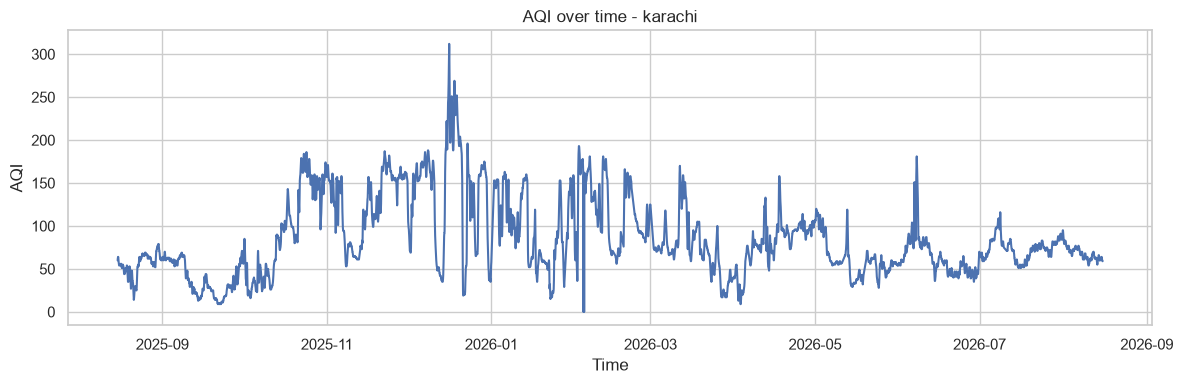

In [18]:
for city, group in df.groupby("city"):
    plt.figure(figsize=(12, 4))
    plt.plot(group["timestamp"], group["aqi"])
    plt.title(f"AQI over time - {city}")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.tight_layout()
    plt.show()

## AQI distribution

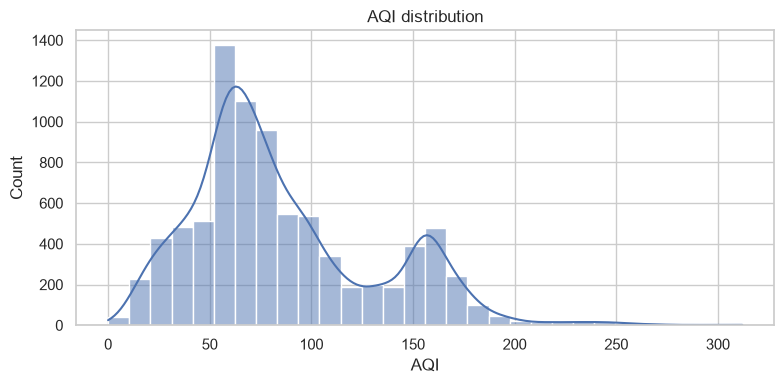

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df["aqi"].dropna(), bins=30, kde=True)
plt.title("AQI distribution")
plt.xlabel("AQI")
plt.tight_layout()
plt.show()

## Hourly and day-of-week patterns

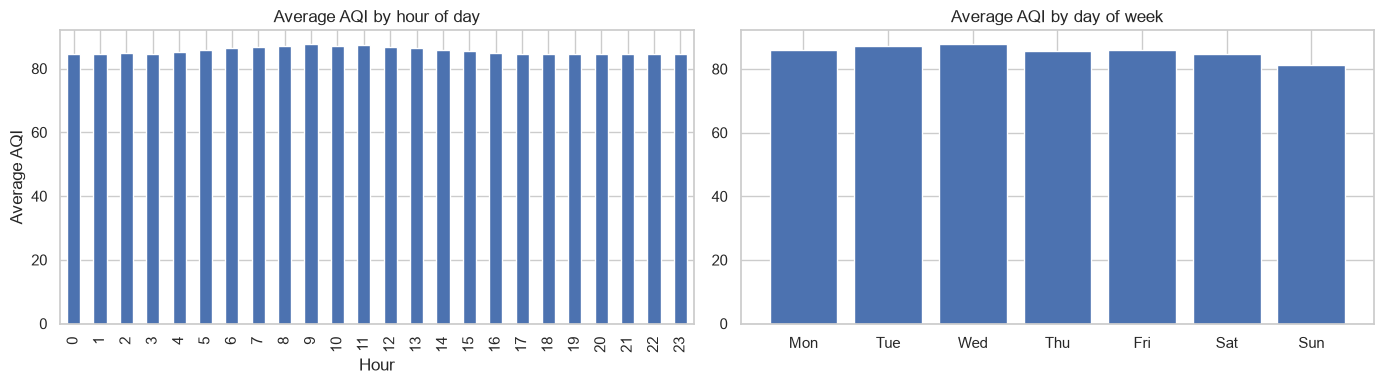

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby("hour")["aqi"].mean().plot(kind="bar", ax=axes[0], title="Average AQI by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average AQI")

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
avg_by_dow = df.groupby("day_of_week")["aqi"].mean()
axes[1].bar([day_names[i] for i in avg_by_dow.index], avg_by_dow.values)
axes[1].set_title("Average AQI by day of week")

plt.tight_layout()
plt.show()

## Correlations between pollutants/weather and AQI

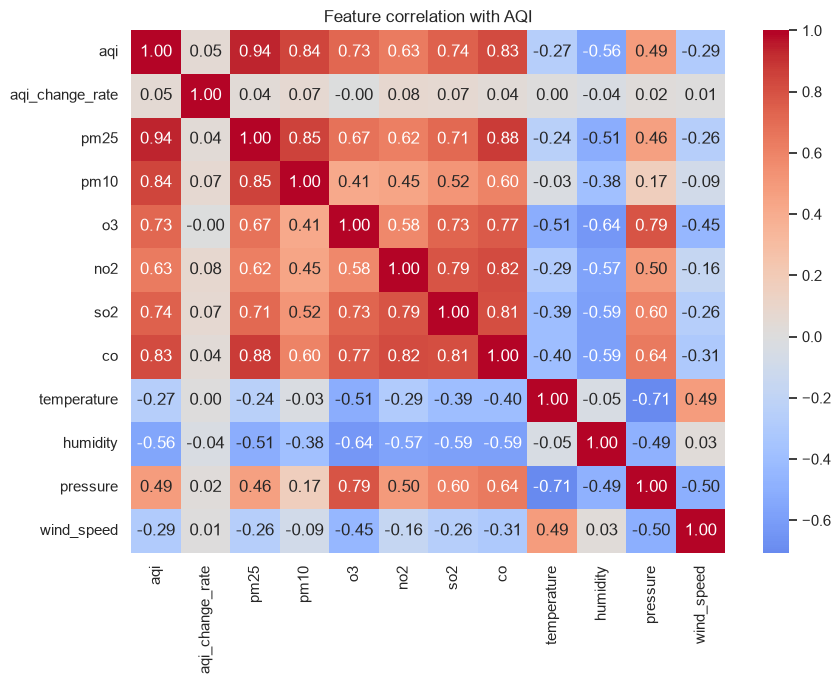

In [21]:
numeric_cols = [
    "aqi", "aqi_change_rate", "pm25", "pm10", "o3", "no2", "so2", "co",
    "temperature", "humidity", "pressure", "wind_speed",
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation with AQI")
plt.tight_layout()
plt.show()